Saving SkinColor.zip to SkinColor.zip
Content: ['.config', 'FacePhoto', 'SkinColor.zip', 'GroundT_FacePhoto', 'FamilyPhoto', 'GroundT_FamilyPhoto', 'sample_data']
Base folder: /content
Face Dir: /content/FacePhoto
Mask Dir: /content/GroundT_FacePhoto


/tmp/ipykernel_635/2451613238.py:56: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imread(os.path.join(image_folder, img_file)))
/tmp/ipykernel_635/2451613238.py:57: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  masks.append(imread(os.path.join(mask_folder, mask_file)))


Total Images: 32
Image: m(01-32)_gr.jpg
Skin Pixels: 50427
Skin Percentage: 39.40%
---------------------------


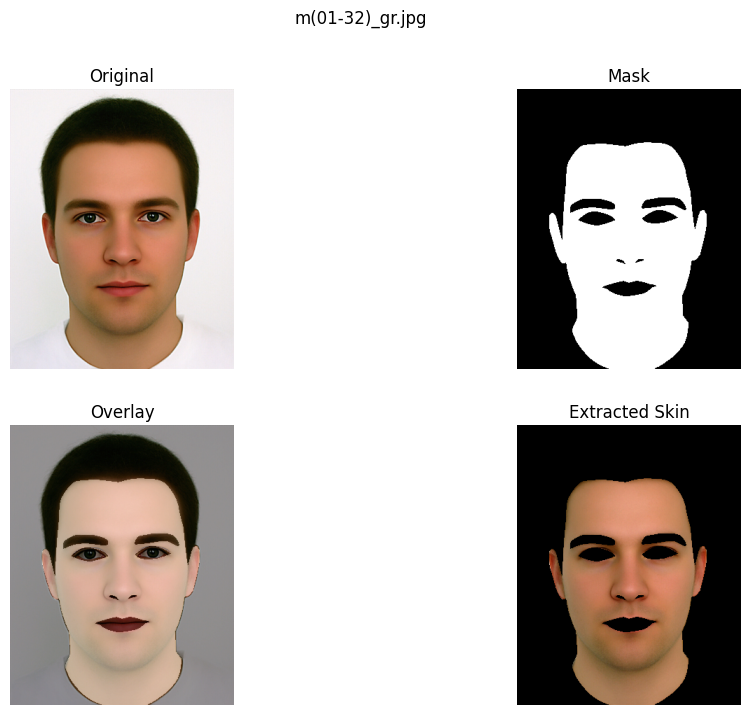

Image: mandy-moore-face-wallpapers_1913_1600.jpg
Skin Pixels: 101884
Skin Percentage: 33.17%
---------------------------


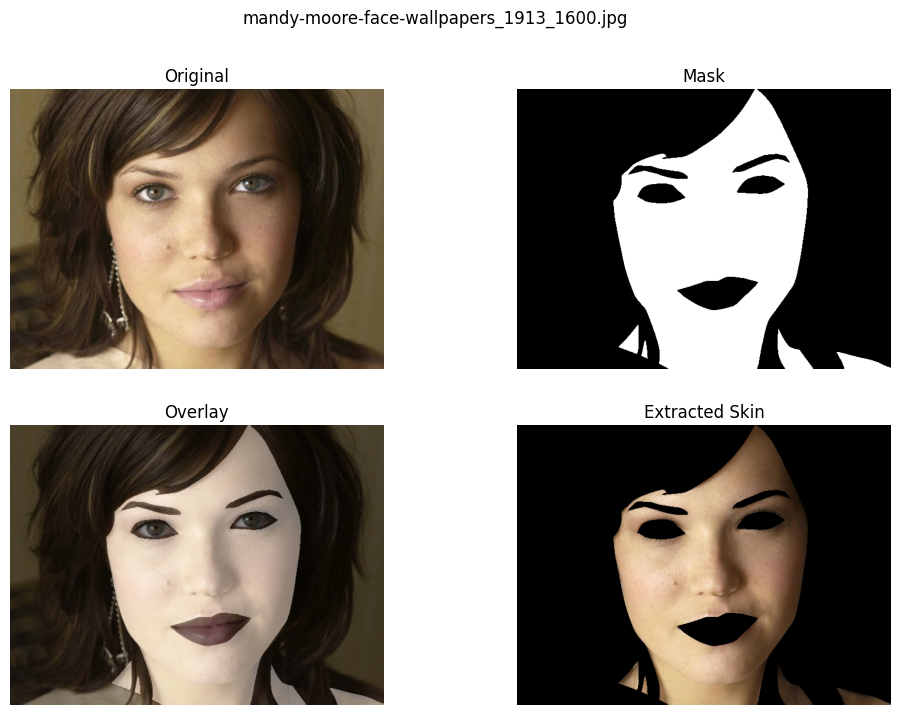

Image: dulani_anuradha4.jpg
Skin Pixels: 18715
Skin Percentage: 27.85%
---------------------------


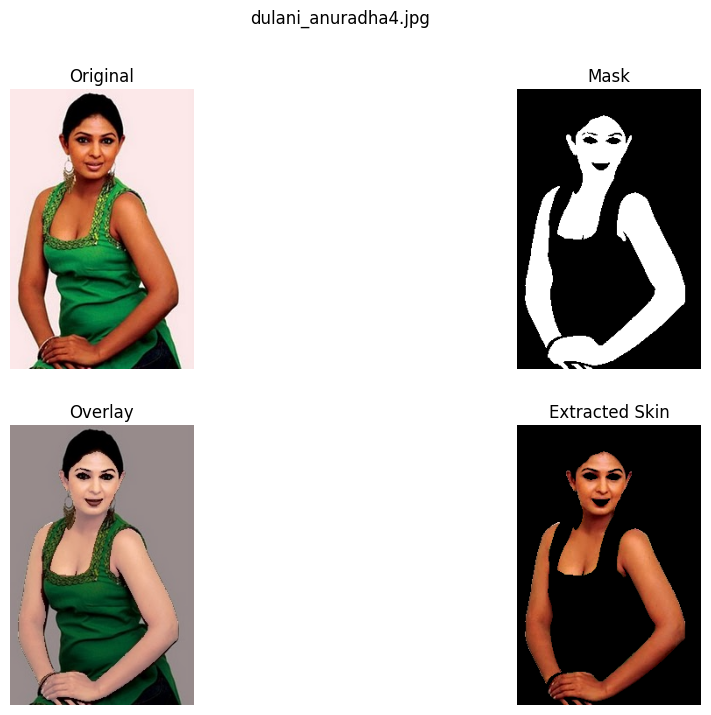

In [1]:
from google.colab import files
uploaded = files.upload()


import zipfile
import os

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("/content/")

all_items = os.listdir("/content")
print("Content:", all_items)

base_folder = None

for item in all_items:
    item_path = os.path.join("/content", item)
    if os.path.isdir(item_path):
        sub = os.listdir(item_path)
        if any("FacePhoto" in s for s in sub):
            base_folder = item_path
            break


if base_folder is None:
    base_folder = "/content"

print("Base folder:", base_folder)

subfolders = os.listdir(base_folder)

face_dir = os.path.join(base_folder, [f for f in subfolders if "FacePhoto" in f][0])
mask_dir = os.path.join(base_folder, [f for f in subfolders if "GroundT" in f][0])

print("Face Dir:", face_dir)
print("Mask Dir:", mask_dir)

import numpy as np
import matplotlib.pyplot as plt
from imageio import imread


def load_images(image_folder, mask_folder):
    images, masks, names = [], [], []

    image_files = os.listdir(image_folder)
    mask_files = os.listdir(mask_folder)

    for img_file in image_files:
        name = os.path.splitext(img_file)[0]

        for mask_file in mask_files:
            if name == os.path.splitext(mask_file)[0]:
                images.append(imread(os.path.join(image_folder, img_file)))
                masks.append(imread(os.path.join(mask_folder, mask_file)))
                names.append(img_file)
                break

    return images, masks, names

def extract_skin(image, mask):
    mask_rgb = mask[:, :, :3]
    skin_pixels = np.all(mask_rgb == [255,255,255], axis=-1)

    skin_image = np.zeros_like(image)
    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels

def display_results(image, mask, skin_image, name):
    plt.figure(figsize=(12,8))

    plt.subplot(2,2,1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.suptitle(name)
    plt.show()


images, masks, names = load_images(face_dir, mask_dir)

print("Total Images:", len(images))

for i in range(len(images)):
    skin_image, skin_pixels = extract_skin(images[i], masks[i])

    total_pixels = skin_pixels.size
    skin_count = np.sum(skin_pixels)
    percentage = (skin_count / total_pixels) * 100

    print("Image:", names[i])
    print("Skin Pixels:", skin_count)
    print("Skin Percentage: %.2f%%" % percentage)
    print("---------------------------")

    display_results(images[i], masks[i], skin_image, names[i])

    if i == 2:
        break